In [2]:
# Install necessary libraries (if not already installed in the environment)
!pip install wfdb
!pip install numpy==1.23.5

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import glob
import random
import gc
import mne
from scipy.signal import resample
import tqdm
import logging
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
from torch.utils.data import DataLoader, TensorDataset

# Verify the numpy version to make sure it's correctly installed
import numpy as np
print(np.__version__)  # Should print 1.23.5 if the installation worked


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.3/162.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 75.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.19 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
albumentations 1.4.20 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
bayesian-optimization 2.0.3 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
bigframes 1.29.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
chex 0.1.88 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
featuretools 1.31.0 requires numpy>=1.25.0, bu

In [3]:
import os
import gc
import glob
import random
import logging
import numpy as np
import tqdm
import mne
import wfdb
import torch
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import DataLoader, TensorDataset

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Suppress MNE logging
mne.set_log_level(verbose='ERROR')

# EEG Channel list (Bipolar Montage)
CH_LABELS = ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 
             'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-1', 'P8-O2', 
             'FZ-CZ', 'CZ-PZ']

# Dataset path
DATASET_PATH = '/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0'


def check_data(X, Y=None, stage="Raw"):
    """Prints dataset statistics and sample values."""
    logger.info(f"[{stage} Data]")
    logger.info(f"Shape of X: {X.shape}")
    if Y is not None:
        logger.info(f"Shape of Y: {Y.shape}")
        logger.info(f"Sample Y[0]: {Y[0]}")
    logger.info(f"Sample X[0, 0, :10]: {X[0, 0, :10]}")
    logger.info(f"Min: {X.min()}, Max: {X.max()}")
    logger.info(f"Number of spikes (if encoded): {X.sum() if np.any(X > 0) else 0}\n")


def normalize_data(X):
    """Normalizes the input data to the range [0,1]."""
    X_min = X.min(axis=(0, 2), keepdims=True)
    X_max = X.max(axis=(0, 2), keepdims=True)
    return (X - X_min) / (X_max - X_min + 1e-8)


def rate_encoding(signal, threshold=None, return_threshold=False):
    """Encodes signals using a rate-based spike encoding."""
    if threshold is None:
        threshold = np.mean(signal) + 2 * np.std(signal)
    spikes = np.where((signal > threshold) & (signal >= 0.65), 1, 0)
    return (spikes, threshold) if return_threshold else spikes


def process_and_save_file(file_path, output_dir, ch_labels, time_window, time_step, downsample_factor):
    """Processes an EEG file, extracts seizure information, and saves processed data."""
    try:
        raw_data = mne.io.read_raw_edf(file_path, preload=False)
        if not all(any(ch in label for label in raw_data.ch_names) for ch in ch_labels):
            return False

        raw_data.pick(ch_labels)
        signals = raw_data.get_data() * 1e6
        fs = int(1 / (raw_data.times[1] - raw_data.times[0]))
        new_timesteps = signals.shape[1] // downsample_factor
        signals = resample(signals, num=new_timesteps, axis=1)
        
        # Seizure annotation processing
        seizure_labels = np.zeros(new_timesteps)
        annotation_path = file_path + '.seizures'
        if os.path.exists(annotation_path):
            annotations = wfdb.rdann(file_path, 'seizures')
            for i in range(0, len(annotations.sample), 2):
                start, end = annotations.sample[i] // downsample_factor, annotations.sample[i+1] // downsample_factor
                seizure_labels[start:end] = 1
        
        # Segmenting EEG signals
        step_window = time_window * fs // downsample_factor
        step = time_step * fs // downsample_factor
        seizure_ratios = [seizure_labels[i * step:i * step + step_window].sum() / step_window 
                          for i in range((new_timesteps - step_window) // step)]
        
        seizure_indices = np.where(np.array(seizure_ratios) > 0)[0]
        non_seizure_indices = random.sample(list(np.where(np.array(seizure_ratios) == 0)[0]), len(seizure_indices))
        
        total_samples = len(seizure_indices) + len(non_seizure_indices)
        
        if total_samples > 0:
            segmented_signals = np.zeros((total_samples, len(ch_labels), step_window), dtype=np.float32)
            labels = np.zeros(total_samples, dtype=bool)
            
            for idx, i in enumerate(list(seizure_indices) + list(non_seizure_indices)):
                segmented_signals[idx] = signals[:, i * step:i * step + step_window]
                labels[idx] = i in seizure_indices
            
            # Normalize and encode spikes
            segmented_signals = normalize_data(segmented_signals)
            spikes = rate_encoding(segmented_signals)
            
            np.save(os.path.join(output_dir, f"signals_{os.path.basename(file_path)}.npy"), spikes)
            np.save(os.path.join(output_dir, f"labels_{os.path.basename(file_path)}.npy"), labels)
            return True
    except Exception as e:
        logger.error(f"Error processing {file_path}: {e}")
        return False


def preprocess_dataset(dataset_path, ch_labels, downsample_factor=5, time_window=8, time_step=4):
    """Preprocesses the CHB-MIT dataset, balances data, and prepares PyTorch loaders."""
    files = glob.glob(f'{dataset_path}/*/*.edf')
    output_dir = "processed_data"
    os.makedirs(output_dir, exist_ok=True)
    
    valid_files = sum(1 for f in tqdm.tqdm(files) if process_and_save_file(f, output_dir, ch_labels, time_window, time_step, downsample_factor))
    
    logger.info(f"Number of valid files processed: {valid_files}")
    
    return None, None


if __name__ == "__main__":
    X, Y = preprocess_dataset(DATASET_PATH, CH_LABELS)
    logger.info("Processing complete.")


100%|██████████| 686/686 [30:11<00:00,  2.64s/it]  


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


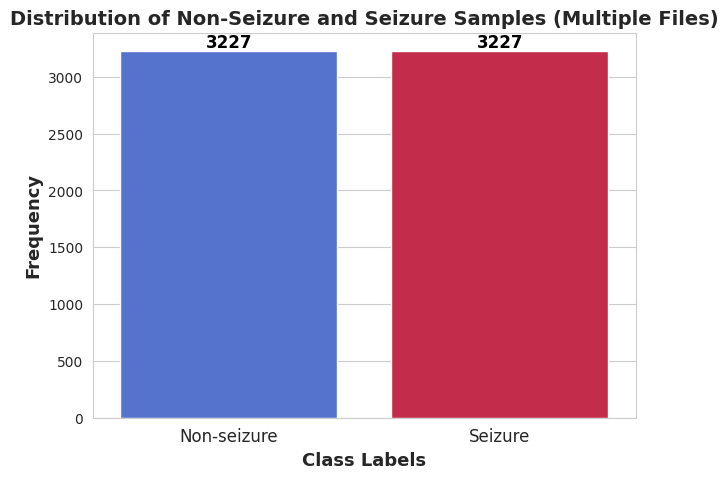

Saved: label_distribution_multiple_npy.png


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Directory containing multiple .npy label files
LABELS_DIR = "/kaggle/working/processed_data"

# Get all label files
label_files = [f for f in os.listdir(LABELS_DIR) if f.startswith("labels_") and f.endswith(".npy")]

# Aggregate labels from all files
all_labels = []
for file in label_files:
    labels = np.load(os.path.join(LABELS_DIR, file), allow_pickle=True)
    all_labels.extend(labels)

# Convert to numpy array
all_labels = np.array(all_labels)

# Count occurrences of each class
unique, counts = np.unique(all_labels, return_counts=True)
class_counts = dict(zip(unique, counts))

# Seaborn configuration
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))

# Draw barplots
colors = ['royalblue', 'crimson']
ax = sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette=colors)

# Annotate bars with counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Set labels and title
plt.xticks([0, 1], labels=['Non-seizure', 'Seizure'], fontsize=12)
plt.xlabel("Class Labels", fontsize=13, fontweight='bold')
plt.ylabel("Frequency", fontsize=13, fontweight='bold')
plt.title("Distribution of Non-Seizure and Seizure Samples (Multiple Files)", fontsize=14, fontweight='bold')

# Save the plot
save_path = "label_distribution_multiple_npy.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {save_path}")

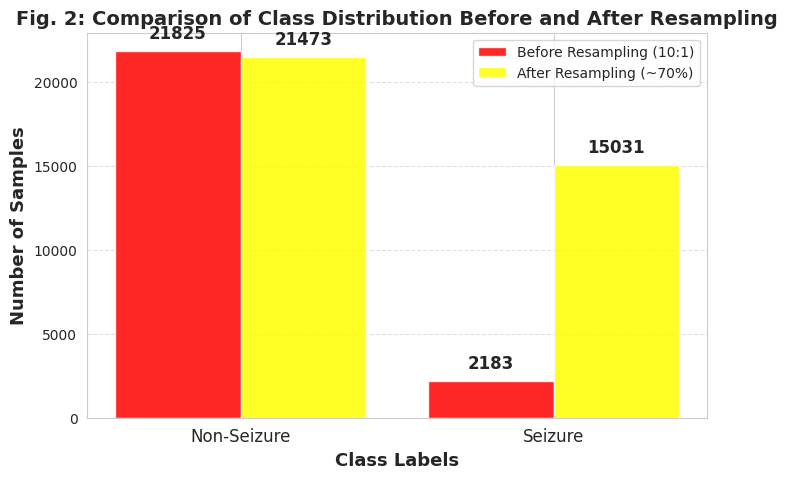

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


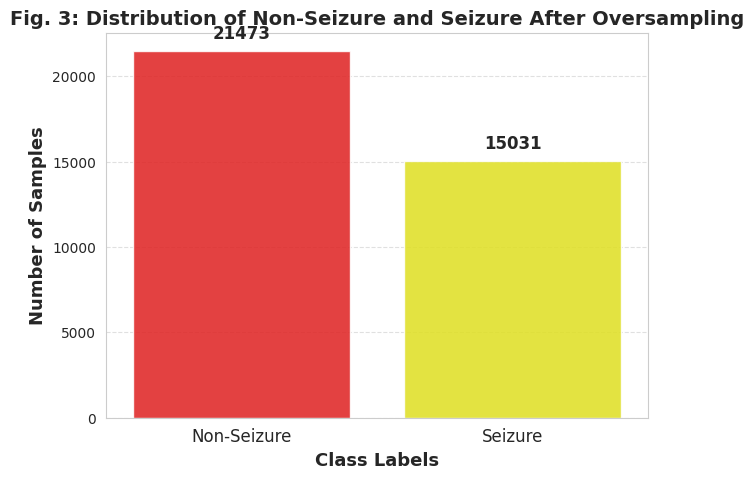

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Configure seaborn style
sns.set_style("whitegrid")

# Sample counts before and after oversampling
before_counts = [21825, 2183]  # Non-Seizure, Seizure (10:1)
after_counts = [21473, 15031]  # Non-Seizure, Seizure (~70% ratio)
labels = ["Non-Seizure", "Seizure"]

# 🎨 Fig. 2: Comparison Before vs After Resampling
plt.figure(figsize=(8, 5))
x = np.arange(len(labels))
width = 0.4

bar1 = plt.bar(x - width/2, before_counts, width=width, alpha=0.85, label="Before Resampling (10:1)", color="red")
bar2 = plt.bar(x + width/2, after_counts, width=width, alpha=0.85, label="After Resampling (~70%)", color="yellow")

# Annotate bars
for bars in [bar1, bar2]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500, f'{int(bar.get_height())}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# Configure axes and title
plt.xticks(x, labels, fontsize=12)
plt.ylabel("Number of Samples", fontsize=13, fontweight='bold')
plt.xlabel("Class Labels", fontsize=13, fontweight='bold')
plt.title("Fig. 2: Comparison of Class Distribution Before and After Resampling", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save Fig. 2
fig2_path = "class_distribution_comparison_improved.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

# 🎨 Fig. 3: Distribution After Oversampling
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=labels, y=after_counts, palette=["red", "yellow"], alpha=0.85)

# Annotate bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height() + 500), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Configure axes and title
plt.xticks(fontsize=12)
plt.ylabel("Number of Samples", fontsize=13, fontweight='bold')
plt.xlabel("Class Labels", fontsize=13, fontweight='bold')
plt.title("Fig. 3: Distribution of Non-Seizure and Seizure After Oversampling", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save Fig. 3
fig3_path = "class_distribution_after_oversampling_improved.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()

logger.info(f"Saved: {fig2_path}, {fig3_path}")


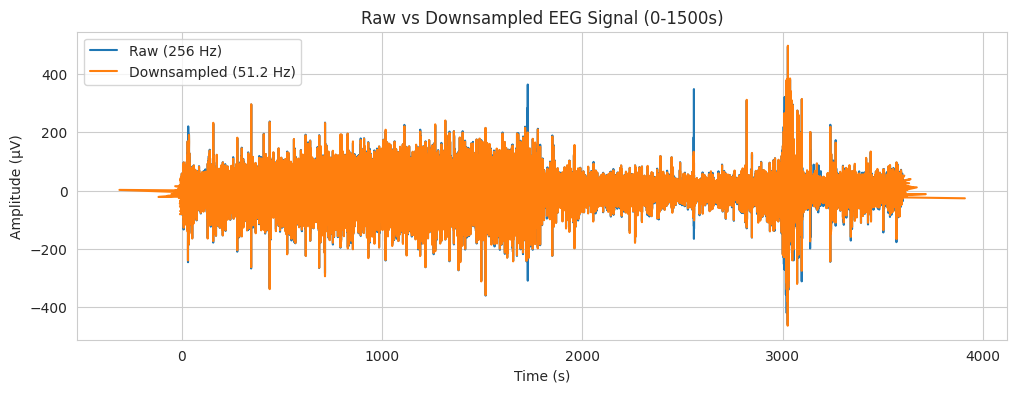

In [6]:
import mne
import matplotlib.pyplot as plt
from scipy.signal import resample

file_path = '/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf'
raw = mne.io.read_raw_edf(file_path, preload=True)
raw.pick(['FP1-F7'])
signal = raw.get_data()[0] * 1e6
times = raw.times[:256*3600]  # Cut 1500 seconds
signal = signal[:256*3600]

downsample_factor = 5
signal_ds = resample(signal, num=len(signal)//downsample_factor)
times_ds = resample(times, num=len(times)//downsample_factor)

plt.figure(figsize=(12, 4))
plt.plot(times[::5], signal[::5], label='Raw (256 Hz)')  # Take every 5 points
plt.plot(times_ds, signal_ds, label='Downsampled (51.2 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('Raw vs Downsampled EEG Signal (0-1500s)')
plt.legend()
plt.show()

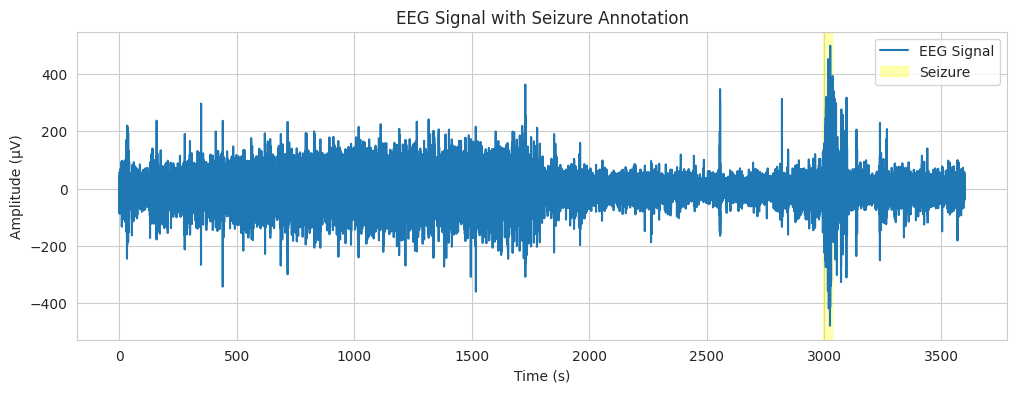

In [7]:
import wfdb
seizure_file = '/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf'
raw = mne.io.read_raw_edf(seizure_file, preload=True)
raw.pick(['FP1-F7'])
signal = raw.get_data()[0] * 1e6
times = raw.times

ann = wfdb.rdann(seizure_file, 'seizures')
seizure_start, seizure_end = ann.sample[0], ann.sample[1]

plt.figure(figsize=(12, 4))
plt.plot(times, signal, label='EEG Signal')
plt.axvspan(times[seizure_start], times[seizure_end], color='yellow', alpha=0.3, label='Seizure')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('EEG Signal with Seizure Annotation')
plt.legend()
plt.show()

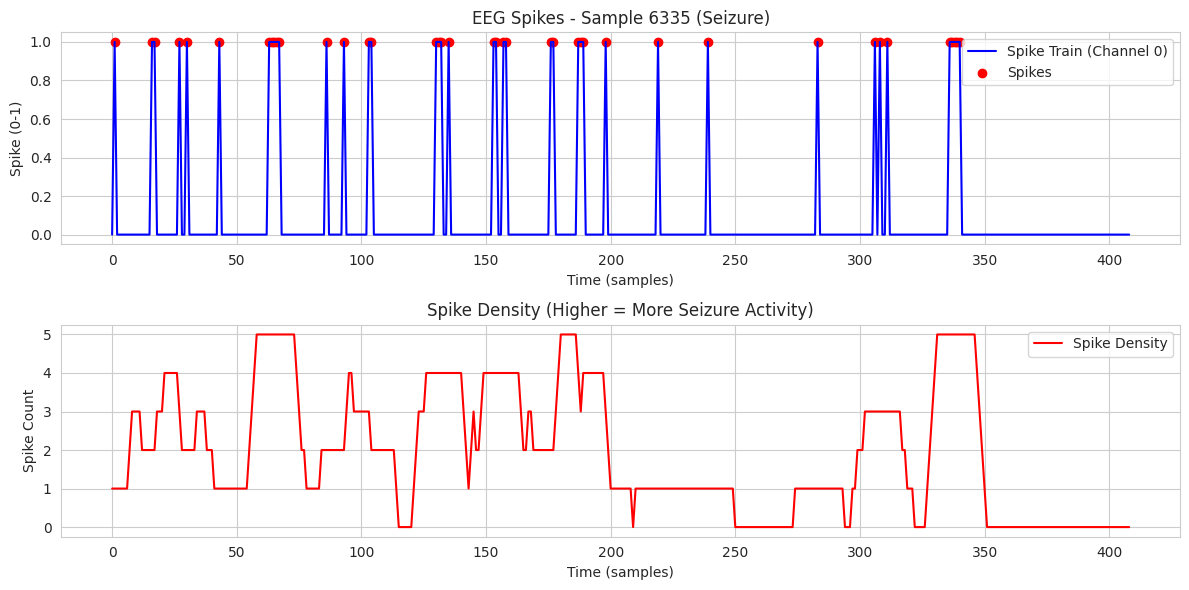

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Directory containing multiple .npy label files
LABELS_DIR = "processed_data"

# Get all signal and label files
label_files = [f for f in os.listdir(LABELS_DIR) if f.startswith("labels_") and f.endswith(".npy")]
signal_files = [f.replace("labels_", "signals_") for f in label_files]

# Aggregate signals and labels from all files
all_signals, all_labels = [], []
for label_file, signal_file in zip(label_files, signal_files):
    labels = np.load(os.path.join(LABELS_DIR, label_file), allow_pickle=True)
    signals = np.load(os.path.join(LABELS_DIR, signal_file), allow_pickle=True)
    all_labels.extend(labels)
    all_signals.append(signals)

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_signals = np.concatenate(all_signals, axis=0)

# Select a sample with label 1 (seizure)
seizure_indices = np.where(all_labels == 1)[0]
sample_idx = np.random.choice(seizure_indices, 1)[0]

# Choose a channel to plot
channel = 0  # Selecting channel 0 for visualization
spike_train = all_signals[sample_idx, channel, :]

# Compute spike density within a moving window
window_size = 20  # Adjust window size based on sampling rate
spike_density = np.convolve(spike_train, np.ones(window_size), mode="same")

# Identify positions where spikes occur (values > 0)
spike_positions = np.where(spike_train > 0)[0]

# Plot spike train and spike density
fig, ax = plt.subplots(2, 1, figsize=(12, 6))

# Plot spike train
ax[0].plot(spike_train, label=f"Spike Train (Channel {channel})", color="blue")
ax[0].scatter(spike_positions, spike_train[spike_positions], color="red", marker='o', label="Spikes")  # Highlight spikes
ax[0].set_title(f"EEG Spikes - Sample {sample_idx} (Seizure)")
ax[0].set_xlabel("Time (samples)")
ax[0].set_ylabel("Spike (0-1)")
ax[0].legend()

# Plot spike density
ax[1].plot(spike_density, color="red", label="Spike Density")
ax[1].set_title("Spike Density (Higher = More Seizure Activity)")
ax[1].set_xlabel("Time (samples)")
ax[1].set_ylabel("Spike Count")
ax[1].legend()

plt.tight_layout()
plt.show()

# Print total spike count for the selected sample and channel
total_spikes = np.sum(spike_train)
logger.info(f"Total spikes in sample {sample_idx} (channel {channel}): {total_spikes}")


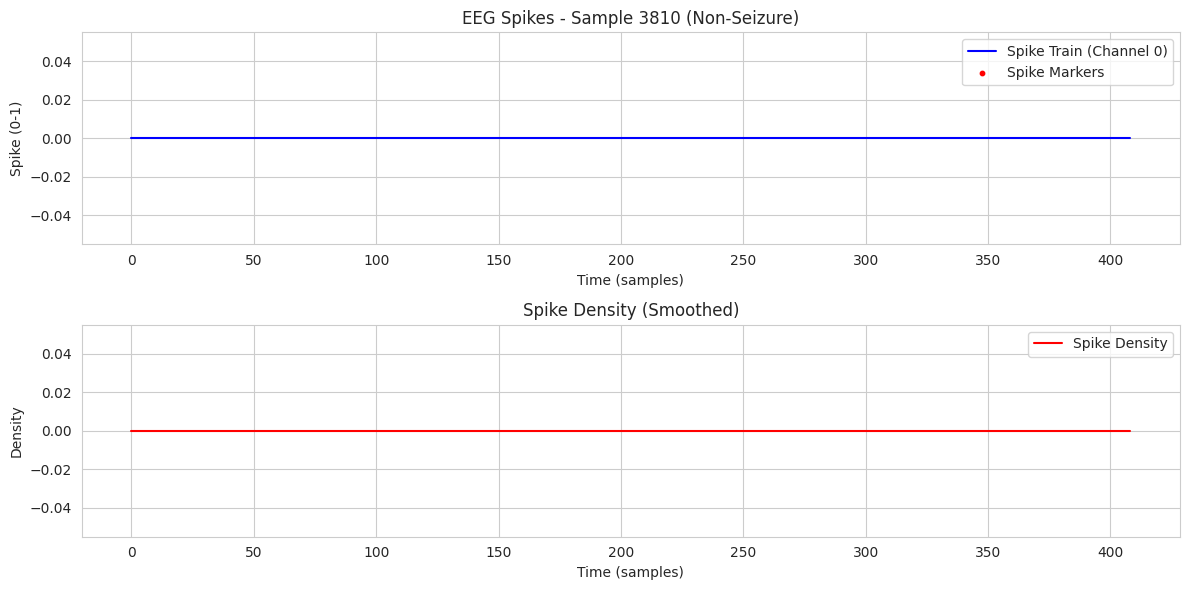

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Directory containing multiple .npy label files
LABELS_DIR = "processed_data"

# Get all signal and label files
label_files = [f for f in os.listdir(LABELS_DIR) if f.startswith("labels_") and f.endswith(".npy")]
signal_files = [f.replace("labels_", "signals_") for f in label_files]

# Aggregate signals and labels from all files
all_signals, all_labels = [], []
for label_file, signal_file in zip(label_files, signal_files):
    labels = np.load(os.path.join(LABELS_DIR, label_file), allow_pickle=True)
    signals = np.load(os.path.join(LABELS_DIR, signal_file), allow_pickle=True)
    all_labels.extend(labels)
    all_signals.append(signals)

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_signals = np.concatenate(all_signals, axis=0)

# Select a sample with label 0 (non-seizure)
non_seizure_indices = np.where(all_labels == 0)[0]
sample_idx = np.random.choice(non_seizure_indices, 1)[0]

# Choose a channel to plot
channel = 0  # Selecting channel 0 for visualization
spike_train = all_signals[sample_idx, channel, :]

# Compute spike density within a moving window
window_size = 50  # Adjust window size based on sampling rate
spike_density = np.convolve(spike_train, np.ones(window_size) / window_size, mode="same")

# Identify positions where spikes occur (values > 0)
spike_positions = np.where(spike_train > 0)[0]

# Plot spike train and spike density
fig, ax = plt.subplots(2, 1, figsize=(12, 6))

# Plot spike train
ax[0].plot(spike_train, label=f"Spike Train (Channel {channel})", color="blue")
ax[0].scatter(spike_positions, spike_train[spike_positions], color="red", s=10, label="Spike Markers")
ax[0].set_title(f"EEG Spikes - Sample {sample_idx} (Non-Seizure)")
ax[0].set_xlabel("Time (samples)")
ax[0].set_ylabel("Spike (0-1)")
ax[0].legend()

# Plot spike density
ax[1].plot(spike_density, color="red", label="Spike Density")
ax[1].set_title("Spike Density (Smoothed)")
ax[1].set_xlabel("Time (samples)")
ax[1].set_ylabel("Density")
ax[1].legend()

plt.tight_layout()
plt.show()

# Print total spike count for the selected sample and channel
total_spikes = np.sum(spike_train)
logger.info(f"Total spikes in sample {sample_idx} (channel {channel}): {total_spikes}")


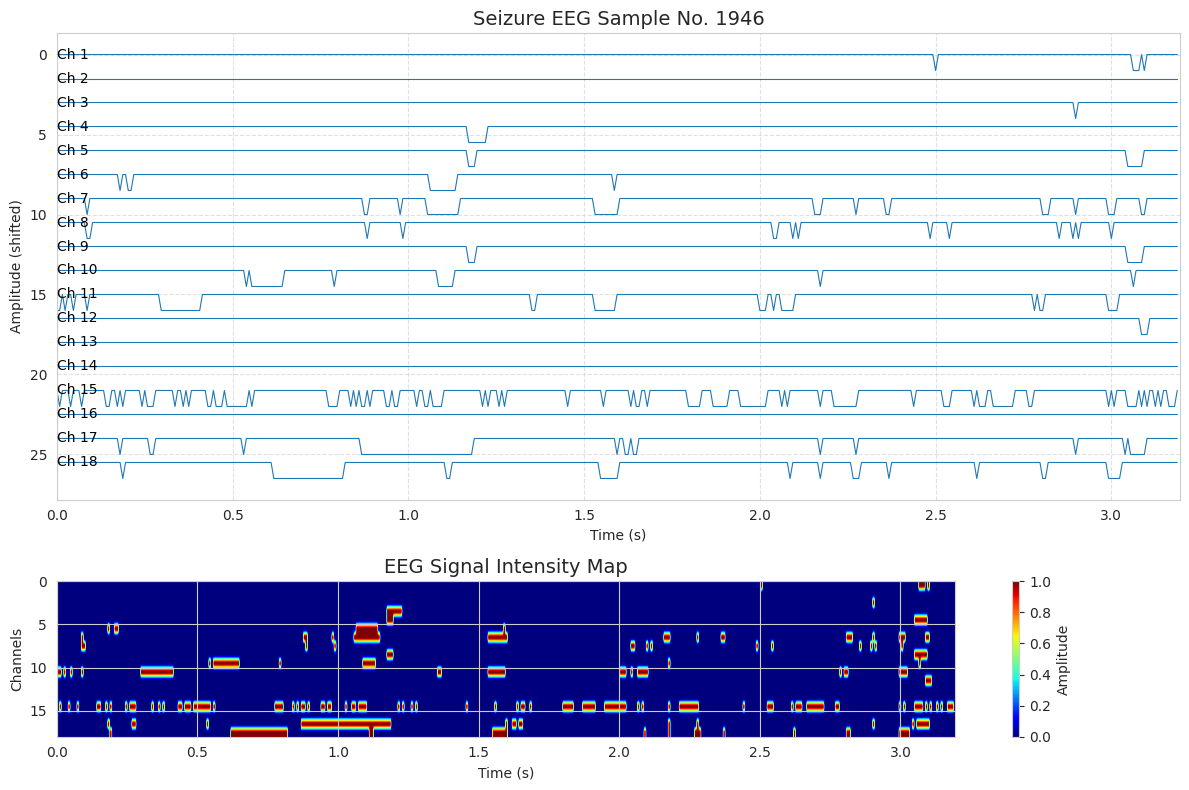

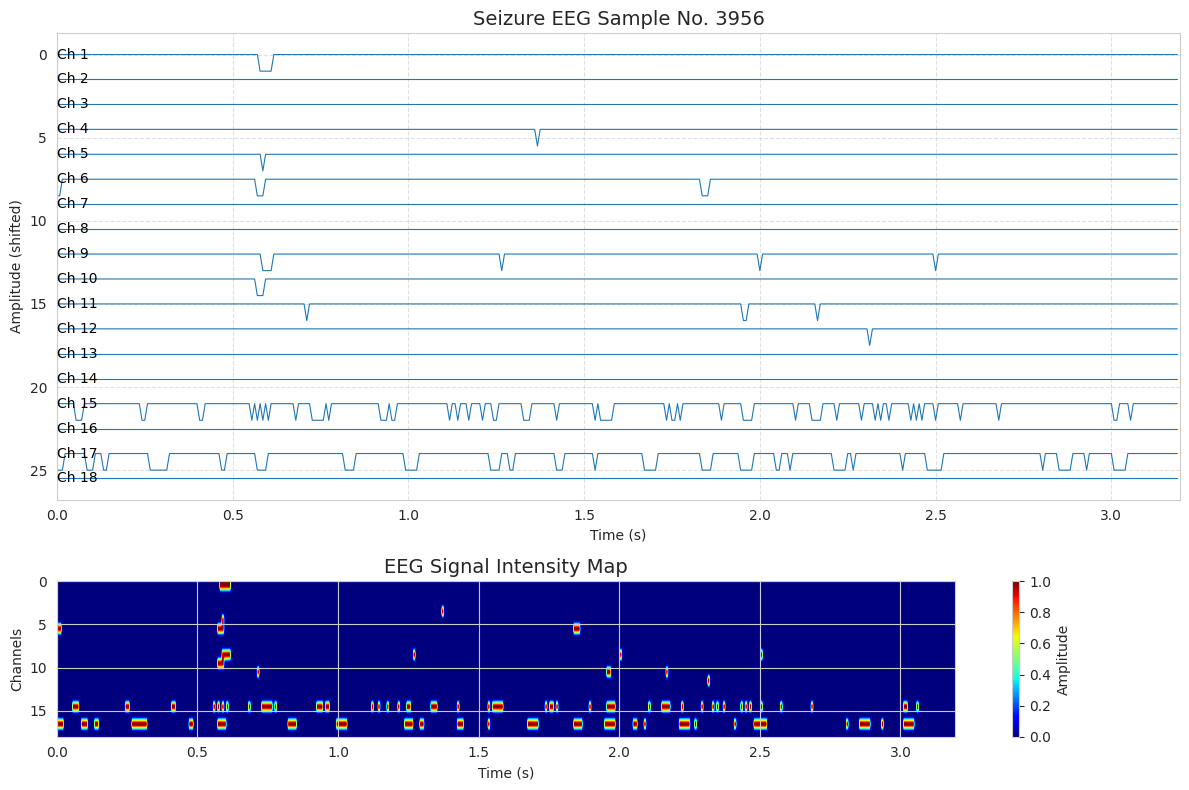

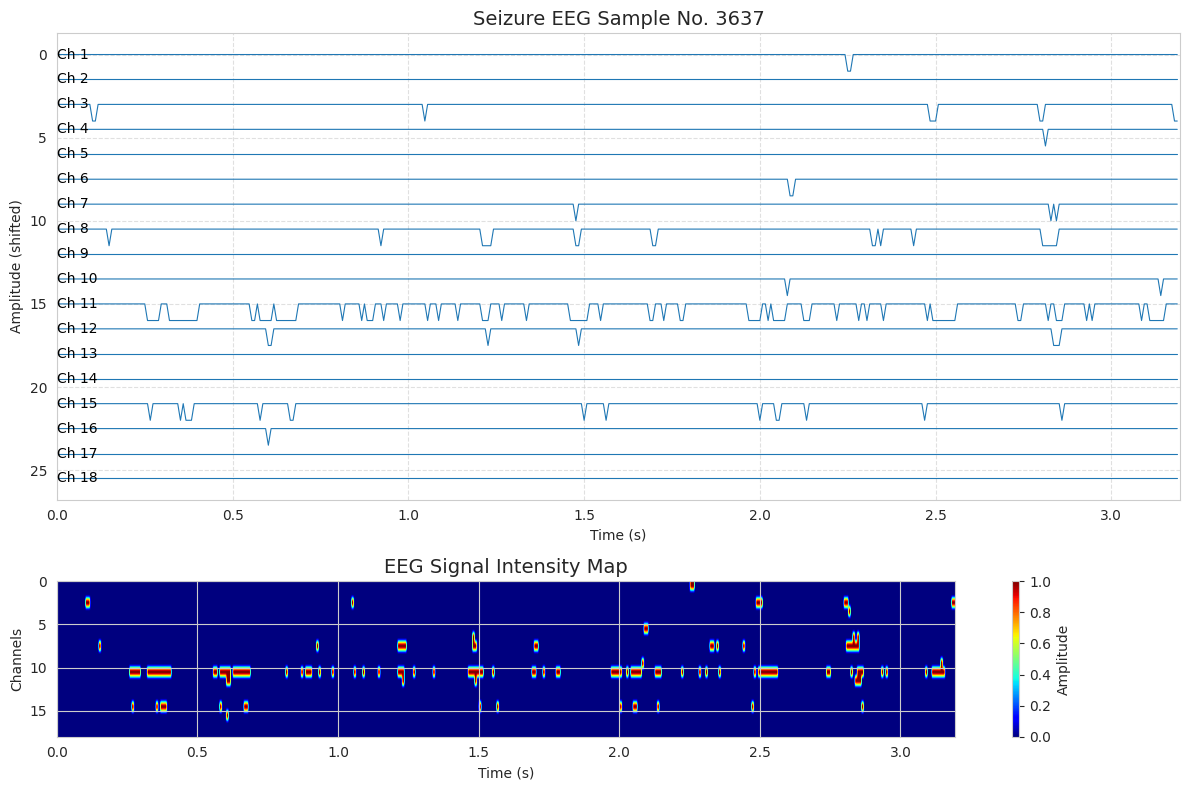

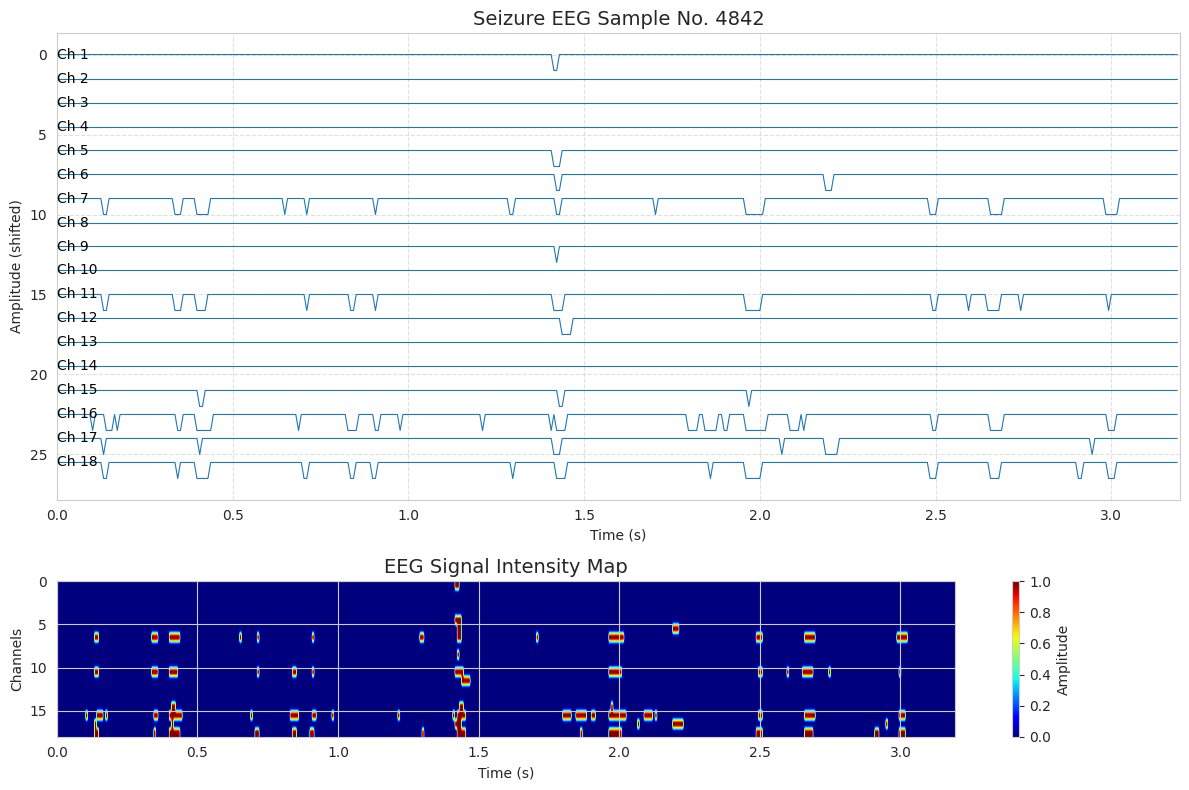

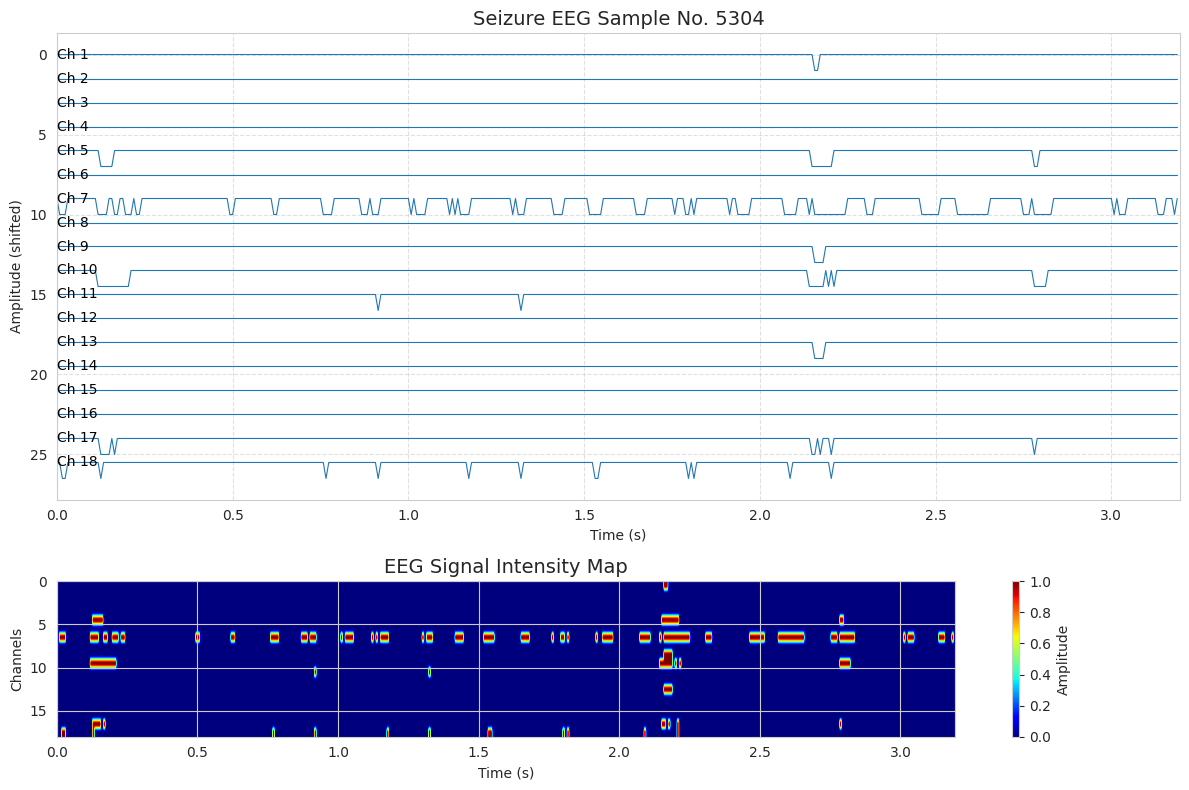

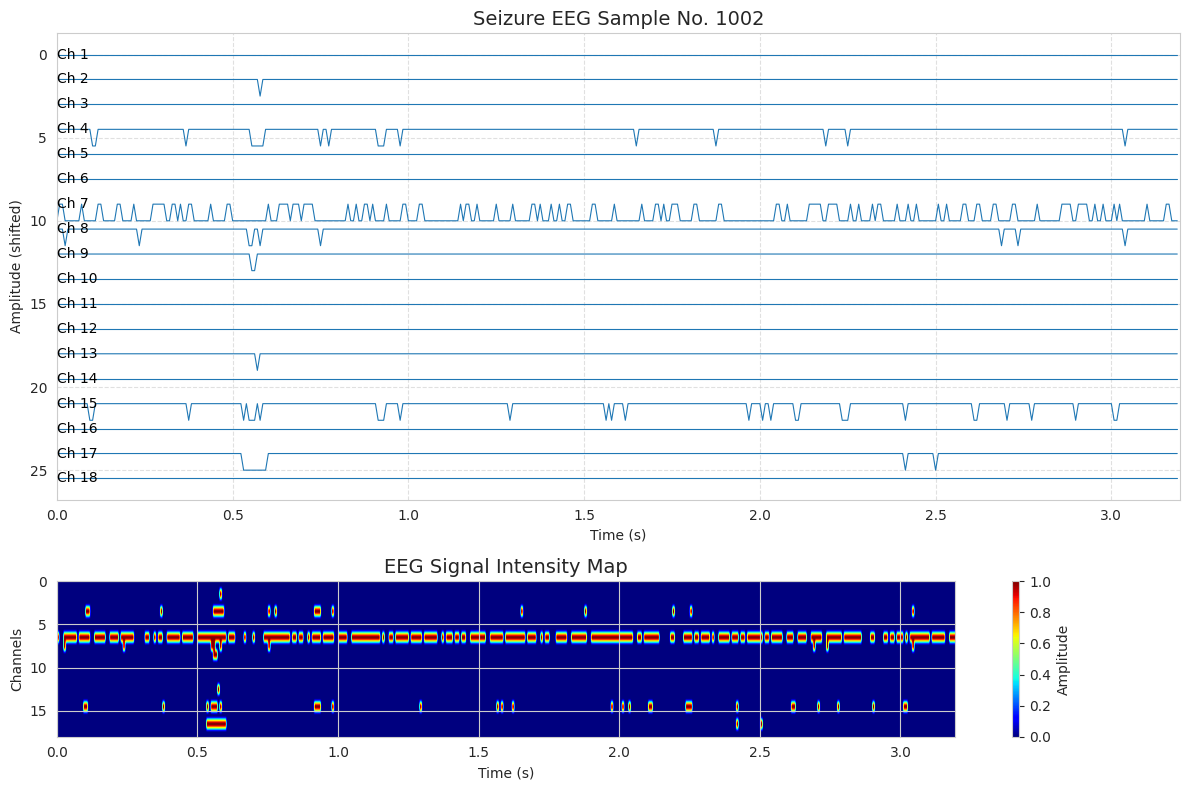

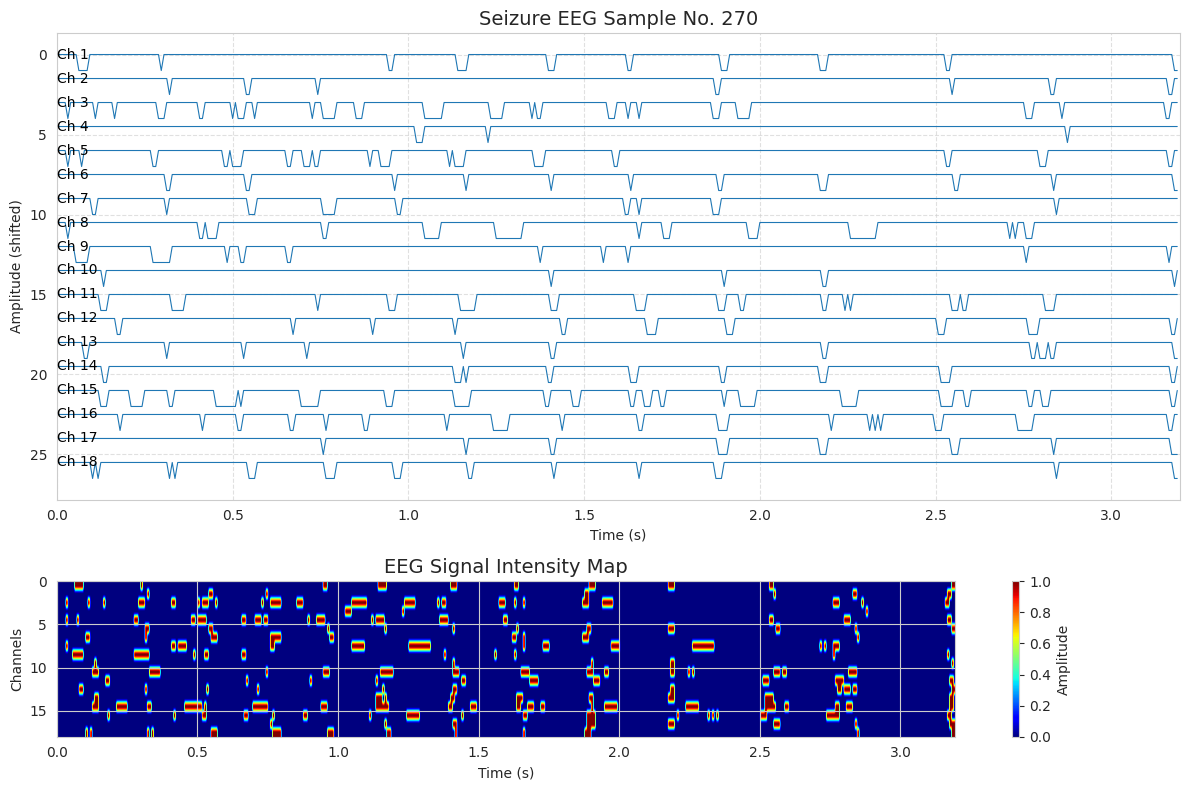

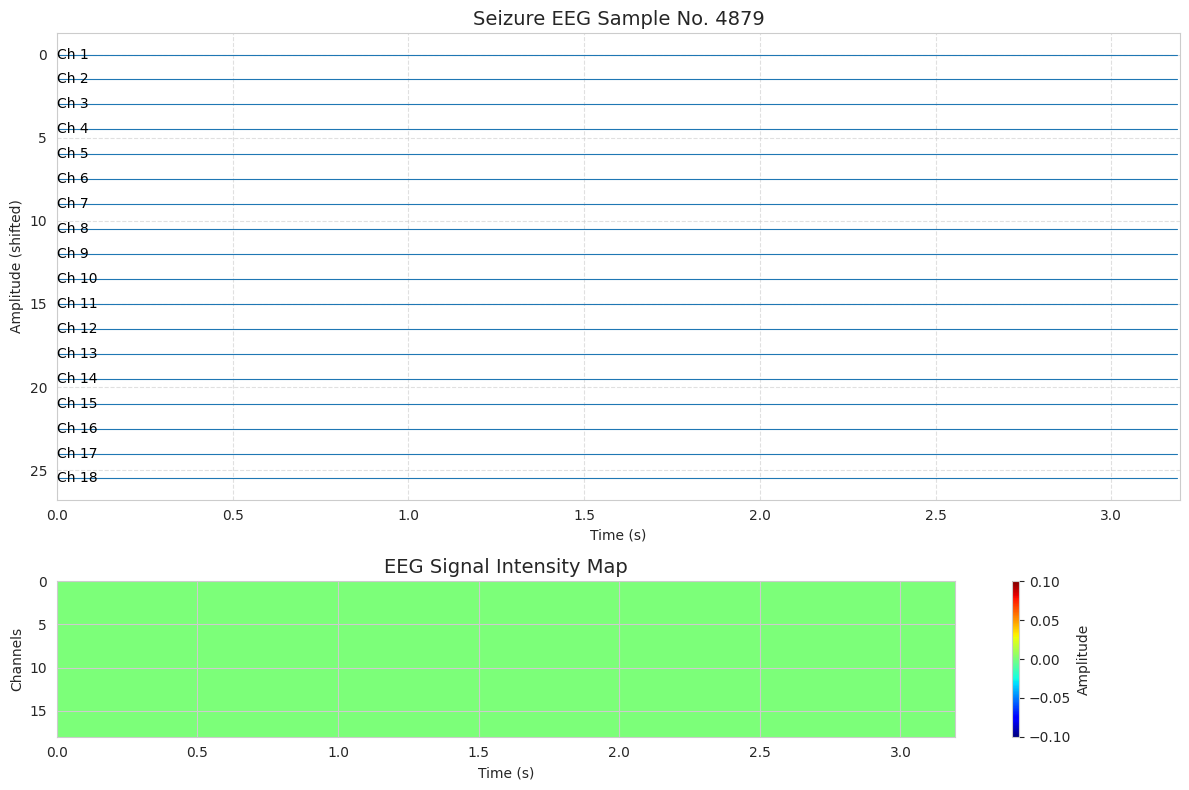

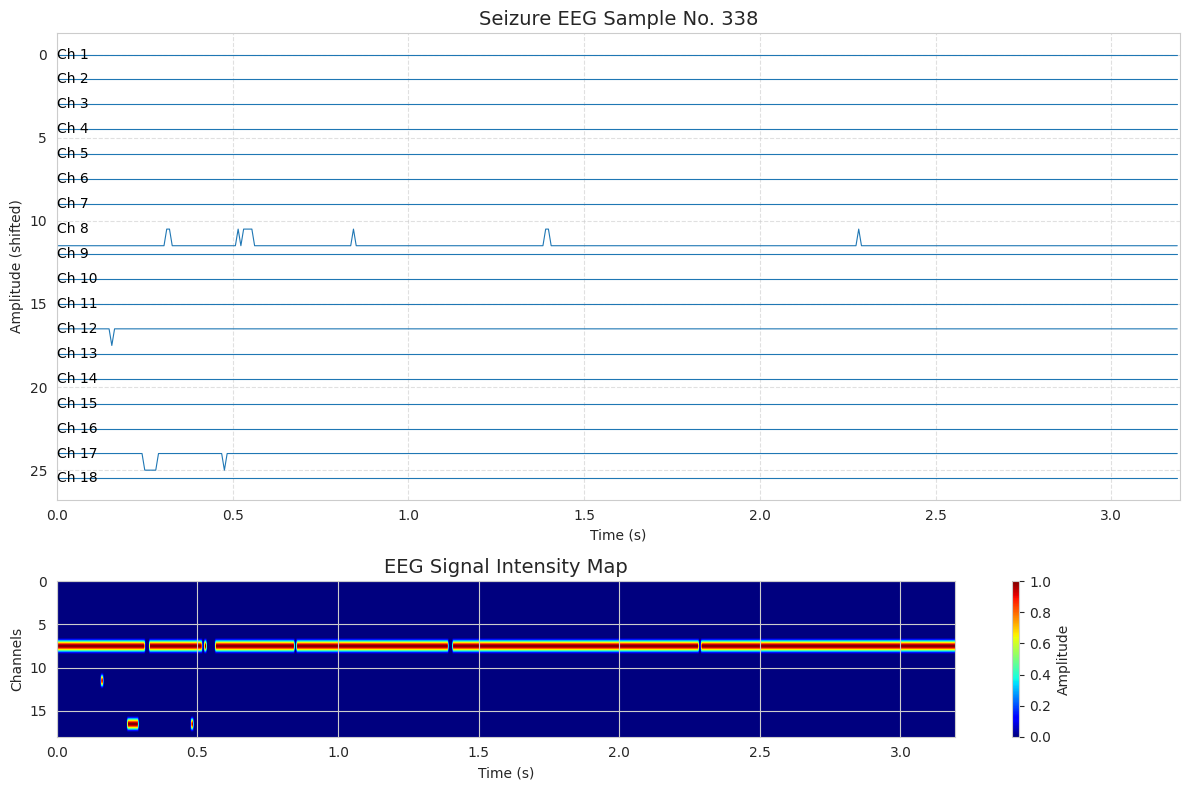

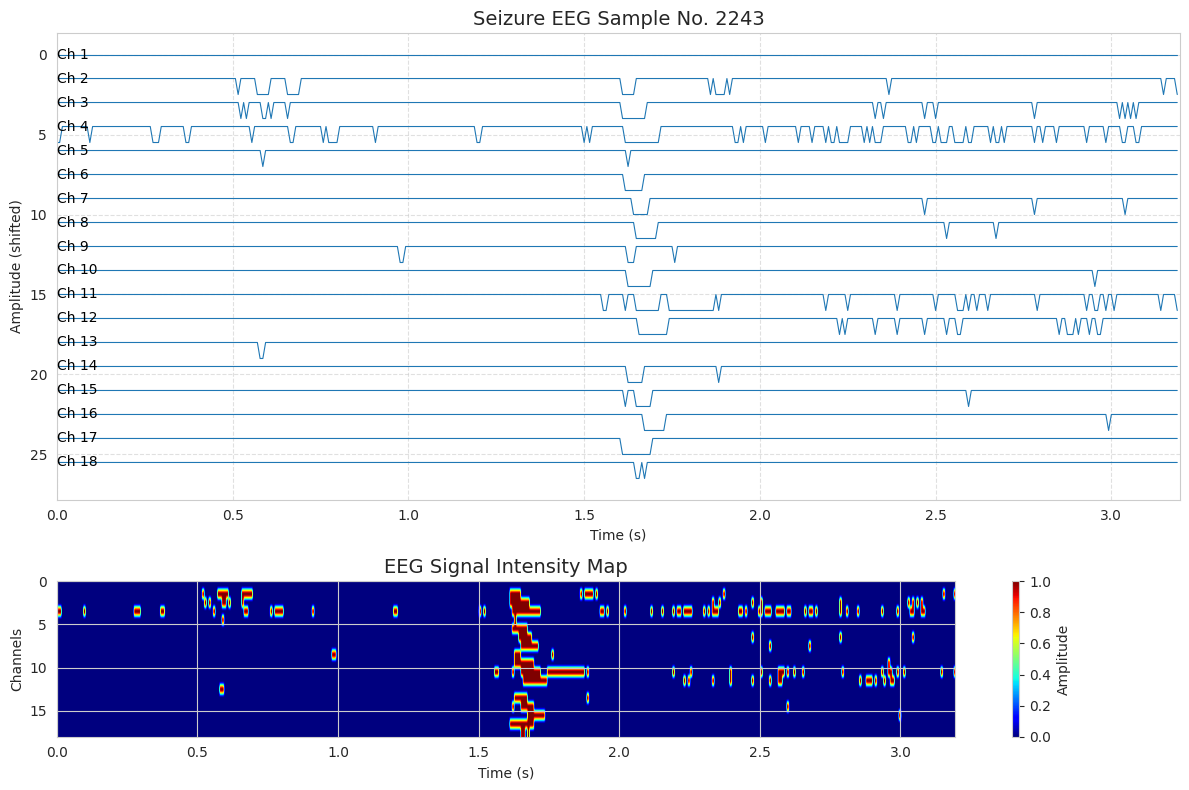

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Directory containing multiple .npy label files
LABELS_DIR = "processed_data"

# Get all signal and label files
label_files = [f for f in os.listdir(LABELS_DIR) if f.startswith("labels_") and f.endswith(".npy")]
signal_files = [f.replace("labels_", "signals_") for f in label_files]

# Aggregate signals and labels from all files
all_signals, all_labels = [], []
for label_file, signal_file in zip(label_files, signal_files):
    labels = np.load(os.path.join(LABELS_DIR, label_file), allow_pickle=True)
    signals = np.load(os.path.join(LABELS_DIR, signal_file), allow_pickle=True)
    all_labels.extend(labels)
    all_signals.append(signals)

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_signals = np.concatenate(all_signals, axis=0)

# Filter only seizure samples
seizure_indices = np.where(all_labels == 1)[0]
selected_samples = random.sample(list(seizure_indices), min(10, len(seizure_indices)))  # Ensure valid sample size

fs = 128  # Sampling frequency (Hz)
vertical_width = np.max(all_signals) * 1.5  # Adjust vertical spacing dynamically

# Generate channel labels
num_channels = all_signals.shape[1]
ch_labels = [f"Ch {i+1}" for i in range(num_channels)]

# Plot 10 EEG seizure samples
for n in selected_samples:
    temp_signals = all_signals[n, :, :]
    time_axis = np.arange(temp_signals.shape[-1]) / fs  # Convert samples to seconds
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Plot EEG signals
    for i in range(temp_signals.shape[0]):
        ax[0].plot(time_axis, temp_signals[i, :] + i * vertical_width, 
                   linewidth=0.8, color='tab:blue')
        ax[0].text(0, i * vertical_width, ch_labels[i], fontsize=10, verticalalignment='center', color='black')

    ax[0].invert_yaxis()
    ax[0].set_xlim(0, temp_signals.shape[-1] / fs)  
    ax[0].set_title(f'Seizure EEG Sample No. {n}', fontsize=14)
    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Amplitude (shifted)')
    ax[0].grid(True, linestyle='--', alpha=0.6)

    # Plot intensity map
    im = ax[1].imshow(temp_signals, aspect='auto', cmap='jet', 
                      extent=[0, temp_signals.shape[-1] / fs, num_channels, 0])
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Channels')
    ax[1].set_title("EEG Signal Intensity Map", fontsize=14)
    fig.colorbar(im, ax=ax[1], label='Amplitude')

    plt.tight_layout()
    plt.show()


GIVES 49.99% ACCURACY

In [11]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ✅ Force PyTorch to use CPU (fixes CUDA issues in Kaggle)
device = torch.device("cpu")
print(f"Using device: {device}")

# Define FocalLoss class
class FocalLoss(nn.Module):
    def __init__(self, gamma=7, alpha=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        targets = targets.float()
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        alpha_weight = self.alpha[1] * targets + self.alpha[0] * (1 - targets)
        F_loss = alpha_weight * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()

# Surrogate gradient function
def surrogate_sigmoid(x, threshold=1.0, sharpness=10.0):
    return torch.sigmoid(sharpness * (x - threshold))

# Define SpikingNeuralNetwork class
class SpikingNeuralNetwork(nn.Module):
    def __init__(self, input_channels, input_timesteps, hidden_sizes=[256, 128, 64, 32]):
        super().__init__()
        self.input_channels = input_channels
        self.input_timesteps = input_timesteps
        self.hidden_sizes = hidden_sizes

        # ✅ Ensure model parameters exist before training
        self.layer1 = nn.Linear(input_channels, hidden_sizes[0])
        self.layer2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.layer3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.layer4 = nn.Linear(hidden_sizes[2], hidden_sizes[3])
        self.output_layer = nn.Linear(hidden_sizes[3], 1)

        self.tau_m = 20.0
        self.threshold = 0.1
        self.reset_potential = 0.0
        self.sharpness = 10.0

    def forward(self, x):
        spikes_input = surrogate_sigmoid(self.layer1(x), self.threshold, self.sharpness)
        spike_outputs_1 = surrogate_sigmoid(self.layer2(spikes_input), self.threshold, self.sharpness)
        spike_outputs_2 = surrogate_sigmoid(self.layer3(spike_outputs_1), self.threshold, self.sharpness)
        spike_outputs_3 = surrogate_sigmoid(self.layer4(spike_outputs_2), self.threshold, self.sharpness)
        output = self.output_layer(spike_outputs_3.mean(dim=1)).squeeze(-1)
        return output

# EEGClassifier class
class EEGClassifier:
    def __init__(self, input_channels, input_timesteps):
        self.device = device  # ✅ Ensures all tensors use CPU
        self.model = SpikingNeuralNetwork(input_channels, input_timesteps).to(self.device)
        self.learning_rate = 0.01
        self.batch_size = 512
        self.epochs = 10

    def prepare_data(self, X, Y):
        X = torch.FloatTensor(X).permute(0, 2, 1).to(self.device)
        Y = torch.FloatTensor(Y).to(self.device)
        dataset = TensorDataset(X, Y)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

    def train(self, train_loader, val_loader, class_weights):
        class_weights = torch.FloatTensor(class_weights).to(self.device)
        criterion = FocalLoss(alpha=class_weights)
        optimizer = torch.optim.Adam([p for p in self.model.parameters() if p.requires_grad], lr=self.learning_rate)  # ✅ Fixes optimizer error

        for epoch in range(self.epochs):
            self.model.train()
            total_loss, correct, total = 0, 0, 0
            for inputs, targets in train_loader:
                optimizer.zero_grad()
                output = self.model(inputs)
                loss = criterion(output, targets)
                loss.backward()
                optimizer.step()

                predictions = (output > 0.1).float()
                correct += (predictions == targets).sum().item()
                total += targets.size(0)
                total_loss += loss.item()

            train_acc = 100 * correct / total
            print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {train_acc:.2f}%")

if __name__ == "__main__":
    LABELS_DIR = "processed_data"
    
    # Load multiple signal and label files
    label_files = [f for f in os.listdir(LABELS_DIR) if f.startswith("labels_") and f.endswith(".npy")]
    signal_files = [f.replace("labels_", "signals_") for f in label_files]

    all_signals, all_labels = [], []
    for label_file, signal_file in zip(label_files, signal_files):
        labels = np.load(os.path.join(LABELS_DIR, label_file), allow_pickle=True)
        signals = np.load(os.path.join(LABELS_DIR, signal_file), allow_pickle=True)
        all_labels.extend(labels)
        all_signals.append(signals)

    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_signals = np.concatenate(all_signals, axis=0)

    # Train/Test Split
    X_train, X_val, Y_train, Y_val = train_test_split(
        all_signals, all_labels, test_size=0.3, stratify=all_labels, random_state=42
    )

    # ✅ Fix class weight handling
    class_weights = compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)
    class_weights = [class_weights[0], class_weights[1]]  # Ensures correct format

    classifier = EEGClassifier(input_channels=18, input_timesteps=409)

    train_loader = classifier.prepare_data(X_train, Y_train)
    val_loader = classifier.prepare_data(X_val, Y_val)

    classifier.train(train_loader, val_loader, class_weights)


Using device: cpu
Epoch 1, Loss: 0.1396, Accuracy: 49.48%
Epoch 2, Loss: 0.0556, Accuracy: 49.77%
Epoch 3, Loss: 0.0499, Accuracy: 49.99%
Epoch 4, Loss: 0.0491, Accuracy: 49.99%
Epoch 5, Loss: 0.0490, Accuracy: 49.99%
Epoch 6, Loss: 0.0488, Accuracy: 49.99%
Epoch 7, Loss: 0.0487, Accuracy: 49.99%
Epoch 8, Loss: 0.0488, Accuracy: 49.99%
Epoch 9, Loss: 0.0488, Accuracy: 49.99%
Epoch 10, Loss: 0.0488, Accuracy: 49.99%


Epoch 300/300 - Train Loss: 0.5017, Train Acc: 83.31%, Val Loss: 0.0370, Val Acc: 77.23%

In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score

# Fix file paths for Kaggle
DATASET_DIR = "/kaggle/working/processed_data"  # Updated path for multiple .npy files

# Load all EEG signal and label files
label_files = [f for f in os.listdir(DATASET_DIR) if f.startswith("labels_") and f.endswith(".npy")]
signal_files = [f.replace("labels_", "signals_") for f in label_files]

all_signals, all_labels = [], []
for label_file, signal_file in zip(label_files, signal_files):
    labels = np.load(os.path.join(DATASET_DIR, label_file), allow_pickle=True)
    signals = np.load(os.path.join(DATASET_DIR, signal_file), allow_pickle=True)
    all_labels.extend(labels)
    all_signals.append(signals)

# Convert lists to numpy arrays
all_labels = np.array(all_labels)
all_signals = np.concatenate(all_signals, axis=0)

# Train-test split
X_train, X_val, Y_train, Y_val = train_test_split(all_signals, all_labels, test_size=0.3, stratify=all_labels, random_state=42)

# Compute class weights
class_weights = compute_class_weight("balanced", classes=[0, 1], y=Y_train)

# Fix device compatibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define FocalLoss
class FocalLoss(nn.Module):
    def __init__(self, gamma=4.0, alpha=0.85):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        targets = targets.float()
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()

# Define Spiking Neural Network
class SpikingNeuralNetwork(nn.Module):
    def __init__(self, input_channels, input_timesteps, hidden_size):
        super().__init__()
        self.input_weights = nn.Linear(input_channels, hidden_size)
        self.hidden_layer1 = nn.Linear(hidden_size, hidden_size // 2)
        self.hidden_layer2 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.hidden_layer3 = nn.Linear(hidden_size // 4, hidden_size // 8)
        self.hidden_layer4 = nn.Linear(hidden_size // 8, 1)

        self.batch_norm1 = nn.BatchNorm1d(hidden_size)
        self.batch_norm2 = nn.BatchNorm1d(hidden_size // 2)
        self.batch_norm3 = nn.BatchNorm1d(hidden_size // 4)
        self.batch_norm4 = nn.BatchNorm1d(hidden_size // 8)

        self.dropout = nn.Dropout(0.45)
        self.tau_m = 20.0
        self.threshold = 0.55
        self.reset_potential = 0.0

    def forward(self, x):
        batch_size = x.shape[0]
        x_reshaped = x.reshape(-1, x.shape[-1])
        hidden_activations = self.input_weights(x_reshaped)
        hidden_activations = self.batch_norm1(hidden_activations)
        hidden_activations = hidden_activations.reshape(batch_size, -1, hidden_activations.shape[-1])

        # Simulate Spiking Behavior
        membrane_potential = torch.zeros(batch_size, hidden_activations.shape[-1], device=x.device)
        spikes = torch.zeros_like(hidden_activations)

        for t in range(x.shape[1]):
            membrane_potential = membrane_potential + (hidden_activations[:, t] - membrane_potential) / self.tau_m
            spike = (membrane_potential >= self.threshold).float()
            spikes[:, t] = spike
            membrane_potential = membrane_potential * (1 - spike) + self.reset_potential * spike

        avg_spikes = torch.mean(spikes, dim=1)
        avg_spikes = self.dropout(avg_spikes)

        hidden = torch.relu(self.batch_norm2(self.hidden_layer1(avg_spikes)))
        hidden = torch.relu(self.batch_norm3(self.hidden_layer2(hidden)))
        hidden = torch.relu(self.batch_norm4(self.hidden_layer3(hidden)))
        output = self.hidden_layer4(hidden)

        return output.squeeze(-1)

# Define EEGClassifier
class EEGClassifier:
    def __init__(self, input_channels, input_timesteps, hidden_size, device="cuda"):
        self.device = device
        self.model = SpikingNeuralNetwork(input_channels, input_timesteps, hidden_size).to(device)
        self.learning_rate = 0.005
        self.batch_size = 126
        self.epochs = 300
        self.threshold = 0.7

    def prepare_data(self, X, Y):
        X = torch.FloatTensor(X).permute(0, 2, 1).to(self.device)
        Y = torch.FloatTensor(Y).to(self.device)
        return DataLoader(dataset=TensorDataset(X, Y), batch_size=self.batch_size, shuffle=True)
    
    def train(self, train_loader, val_loader, class_weights):
        class_weights = torch.FloatTensor(class_weights).to(self.device)
        criterion = FocalLoss(alpha=class_weights[1])
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=3e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

        for epoch in range(self.epochs):
            self.model.train()
            train_loss, train_correct, train_total = 0, 0, 0
            train_preds, train_targets = [], []

            for inputs, targets in train_loader:
                optimizer.zero_grad()
                output = self.model(inputs)
                loss = criterion(output, targets)
                loss.backward()
                optimizer.step()

                preds = (torch.sigmoid(output) > self.threshold).float()
                train_correct += (preds == targets).sum().item()
                train_total += targets.size(0)
                train_loss += loss.item()

                train_preds.extend(preds.cpu().numpy())
                train_targets.extend(targets.cpu().numpy())

            train_acc = 100 * train_correct / train_total
            val_loss, val_acc = self.evaluate(val_loader, criterion)

            print(f"Epoch {epoch+1}/{self.epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

            scheduler.step()
            if val_acc >= 95.0:
                print(f"Early stopping: Validation Accuracy {val_acc:.2f}% at Epoch {epoch+1}")
                break

    def evaluate(self, val_loader, criterion):
        self.model.eval()
        correct, total, total_loss = 0, 0, 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                output = self.model(inputs)
                loss = criterion(output, targets)
                preds = (torch.sigmoid(output) > self.threshold).float()
                correct += (preds == targets).sum().item()
                total += targets.size(0)
                total_loss += loss.item()

        val_acc = 100 * correct / total
        return total_loss / len(val_loader), val_acc

if __name__ == "__main__":
    # Initialize classifier
    classifier = EEGClassifier(input_channels=all_signals.shape[1], input_timesteps=all_signals.shape[2], hidden_size=1024, device=device)

    # Prepare data loaders
    train_loader = classifier.prepare_data(X_train, Y_train)
    val_loader = classifier.prepare_data(X_val, Y_val)

    # Train model
    classifier.train(train_loader, val_loader, class_weights)


Epoch 1/300 - Train Loss: 1.4946, Train Acc: 55.52%, Val Loss: 0.0424, Val Acc: 50.03%
Epoch 2/300 - Train Loss: 1.2056, Train Acc: 56.90%, Val Loss: 0.0344, Val Acc: 53.38%
Epoch 3/300 - Train Loss: 1.1833, Train Acc: 55.92%, Val Loss: 0.0317, Val Acc: 57.51%
Epoch 4/300 - Train Loss: 1.1417, Train Acc: 57.10%, Val Loss: 0.0328, Val Acc: 60.14%
Epoch 5/300 - Train Loss: 1.1243, Train Acc: 57.96%, Val Loss: 0.0313, Val Acc: 60.56%
Epoch 6/300 - Train Loss: 1.1143, Train Acc: 58.78%, Val Loss: 0.0313, Val Acc: 58.44%
Epoch 7/300 - Train Loss: 1.0799, Train Acc: 58.69%, Val Loss: 0.0307, Val Acc: 60.82%
Epoch 8/300 - Train Loss: 1.0773, Train Acc: 59.84%, Val Loss: 0.0305, Val Acc: 60.66%
Epoch 9/300 - Train Loss: 1.0573, Train Acc: 60.13%, Val Loss: 0.0297, Val Acc: 59.11%
Epoch 10/300 - Train Loss: 1.0488, Train Acc: 60.22%, Val Loss: 0.0315, Val Acc: 61.13%
Epoch 11/300 - Train Loss: 1.0189, Train Acc: 60.86%, Val Loss: 0.0302, Val Acc: 60.87%
Epoch 12/300 - Train Loss: 1.0362, Train 

In [ ]:
print("hello")